# 📍 Analítica Espacial: Arreglos y Tablas

 #📍 Vectores y matrices (alternativas a NumPy)

In [ ]:
# #| eval: false

# 1. Importamos la librería estándar para cálculo numérico
import numpy as np

In [3]:
# 2. Arreglos 1D (Vectores): Elevaciones en metros
elevaciones = np.array([2640, 1495, 1018, 18, 959])
print(f"Elevaciones (1D): {elevaciones}")
print(f"Tipo de dato interno: {elevaciones.dtype}")
print(f"Forma (Shape): {elevaciones.shape}\n")

Elevaciones (1D): [2640 1495 1018   18  959]
Tipo de dato interno: int64
Forma (Shape): (5,)



In [4]:
# 3. Arreglos 2D (Matrices): [Latitud, Longitud]
# Representan a: Bogotá, Medellín, Cali
coordenadas = np.array([
    [4.7110, -74.0721],  
    [6.2442, -75.5812],  
    [3.4516, -76.5320]   
])
print(f"Coordenadas (2D):\n{coordenadas}")
print(f"Forma de la matriz: {coordenadas.shape} (Filas, Columnas)")


Coordenadas (2D):
[[  4.711  -74.0721]
 [  6.2442 -75.5812]
 [  3.4516 -76.532 ]]
Forma de la matriz: (3, 2) (Filas, Columnas)


In [5]:
# 4. Generadores automáticos (útiles para cuadrículas o rasters vacíos)
matriz_vacia = np.zeros((10, 10)) # Matriz 10x10 llena de ceros
print(f"Matriz 10x10 (2D):\n{matriz_vacia}")

rango_anios = np.arange(2015, 2026, 1) # Serie del 2015 al 2025
print(f"\nRango de años generado: {rango_anios}")

Matriz 10x10 (2D):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

Rango de años generado: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]


 #📍 Álgebra de matrices y estadística (vectorización)

In [6]:
# 1. Operaciones matemáticas vectorizadas
elevaciones_m = np.array([2640, 1495, 1018, 18, 959])
# Multiplicamos toda la matriz de golpe para convertir a pies (ft)
elevaciones_ft = elevaciones_m * 3.28084  
print(f"Elevaciones en pies: {np.round(elevaciones_ft, 1)}")

Elevaciones en pies: [8661.4 4904.9 3339.9   59.1 3146.3]


In [7]:
# 2. Funciones trigonométricas (vitales para proyecciones)
latitudes = np.array([0, 4.71, 10.96]) # Ecuador, Bogotá, B/quilla
lat_radianes = np.radians(latitudes)
seno_lat = np.sin(lat_radianes)
print(f"Seno de las latitudes: {np.round(seno_lat, 3)}")

Seno de las latitudes: [0.    0.082 0.19 ]


In [8]:
# 3. Estadística Espacial
perfil = np.array([1245, 1367, 1423, 1389, 1456, 1502, 1478, 1398, 1334, 1278])
print(f"\n--- Estadísticas del Transecto ---")
print(f"Media: {np.mean(perfil):.2f} m")
print(f"Mediana: {np.median(perfil):.2f} m")
print(f"Desviación estándar: {np.std(perfil):.2f} m")
print(f"Valor mínimo: {np.min(perfil)} m")
print(f"Valor máximo: {np.max(perfil)} m")
print(f"Desnivel total: {np.ptp(perfil)} m")


--- Estadísticas del Transecto ---
Media: 1387.00 m
Mediana: 1393.50 m
Desviación estándar: 79.34 m
Valor mínimo: 1245 m
Valor máximo: 1502 m
Desnivel total: 257 m


 #📍 Slicing e indexación booleana (filtros espaciales)

In [9]:
# Simulamos la elevación de 6 estaciones andinas
estaciones = np.array([2800, 3100, 2400, 3500, 1900, 3800])

# 1. Slicing (cortes basados en posiciones)
# Python omite el último límite (1:4 extraerá los índices 1, 2 y 3)
tramo_medio = estaciones[1:4]
print(f"Estaciones (índices 1 al 3): {tramo_medio}")

Estaciones (índices 1 al 3): [3100 2400 3500]


In [10]:
# 2. Indexación Booleana (Filtros)
# Creamos una máscara (True/False) para datos en zona de páramo (> 3000m)
mascara_paramo = estaciones > 3000
print(f"\nMáscara booleana: {mascara_paramo}")

# Aplicamos la máscara a los datos originales
estaciones_paramo = estaciones[mascara_paramo]
print(f"Estaciones que superan los 3000m: {estaciones_paramo}")


Máscara booleana: [False  True False  True False  True]
Estaciones que superan los 3000m: [3100 3500 3800]


In [11]:
# 3. Modificación masiva
# A veces necesitamos clasificar datos (ej. valores nulos a -9999)
estaciones[estaciones <2500] = 0 # Convertir pisos calidos/templados a 0 
print(f"\nDatos tras modificación masiva: {estaciones}")


Datos tras modificación masiva: [2800 3100    0 3500    0 3800]


 #📍 Analítica tabular con DataFrames

In [21]:
# #| eval: false

# 1. Importamos la librería líder para manejo de datos
import pandas as pd

# 2. Construimos los datos usando un diccionario (dict)
datos_censo = {
    "Ciudad": ["Bogotá", "Medellín", "Cali", "Barranquilla"],
    "Region": ["Andina", "Andina", "Pacífica", "Caribe"],
    "Poblacion": [7181469, 2529403, 2227642, 1206319],
    "Elevacion": [2640, 1495, 1018, 18]
}

# 3. Convertimos el diccionario en un DataFrame estructurado
df = pd.DataFrame(datos_censo)

print("DataFrame Original:")
print(df)
print(f"\nResumen rápido de tipos de datos:")
print(df.dtypes)

DataFrame Original:
         Ciudad    Region  Poblacion  Elevacion
0        Bogotá    Andina    7181469       2640
1      Medellín    Andina    2529403       1495
2          Cali  Pacífica    2227642       1018
3  Barranquilla    Caribe    1206319         18

Resumen rápido de tipos de datos:
Ciudad         str
Region         str
Poblacion    int64
Elevacion    int64
dtype: object


In [24]:
# #| eval: false

# 1. Selección y Filtros Booleanos
# Extraer ciudades de clima cálido (< 1000m)
ciudades_calidas = df[df["Elevacion"] < 1000]
print("Ciudades de clima cálido:")
print(ciudades_calidas[["Ciudad", "Elevacion", "Region", "Poblacion"]])

Ciudades de clima cálido:
         Ciudad  Elevacion  Region  Poblacion
3  Barranquilla         18  Caribe    1206319


In [26]:
# 2. Agrupación (Groupby)
# Sumar la población agrupando por Región
poblacion_regional = df.groupby("Region")["Poblacion"].sum().reset_index()
print("\nAgrupación - Población por Región:")
print(poblacion_regional)


Agrupación - Población por Región:
     Region  Poblacion
0    Andina    9710872
1    Caribe    1206319
2  Pacífica    2227642


In [28]:
# 3. Cruzar Datos (Merge)
# Un colega nos pasa las temperaturas promedio de las ciudades
temp_data = pd.DataFrame({
    "Ciudad": ["Medellín", "Bogotá", "Barranquilla", "Cali"],
    "Temp_Promedio": [22.0, 14.0, 28.0, 24.0]
})

# Hacemos un cruce (JOIN) de la tabla original con la nueva usando la llave 'Ciudad'
df_enriquecido = pd.merge(df, temp_data, on="Ciudad")
print("\nCruce de Tablas (Merge):")
print(df_enriquecido)


Cruce de Tablas (Merge):
         Ciudad    Region  Poblacion  Elevacion  Temp_Promedio
0        Bogotá    Andina    7181469       2640           14.0
1      Medellín    Andina    2529403       1495           22.0
2          Cali  Pacífica    2227642       1018           24.0
3  Barranquilla    Caribe    1206319         18           28.0


 #📍Manipulación de datos incompletos y visualización

In [30]:
# #| eval: false

import matplotlib.pyplot as plt

# 1. Simulación de falla en un sensor (Falta dato de Cali)
datos_ideam = {
    "Ciudad": ["Bogotá", "Medellín", "Cali", "Barranquilla"],
    "Precipitacion_Anual": [1020, 1656, None, 821] # None indica nulo
}
df_sensor = pd.DataFrame(datos_ideam)
print("Datos con fallos del sensor:")
print(df_sensor)

Datos con fallos del sensor:
         Ciudad  Precipitacion_Anual
0        Bogotá               1020.0
1      Medellín               1656.0
2          Cali                  NaN
3  Barranquilla                821.0


In [31]:
# 2. Imputación: Llenar el vacío (fillna) con la media del resto
media_lluvia = df_sensor["Precipitacion_Anual"].mean()
df_limpio = df_sensor.fillna(value={"Precipitacion_Anual": media_lluvia})
print(f"\nDatos Limpios (Rellenado con media = {media_lluvia:.1f}):")
print(df_limpio)


Datos Limpios (Rellenado con media = 1165.7):
         Ciudad  Precipitacion_Anual
0        Bogotá          1020.000000
1      Medellín          1656.000000
2          Cali          1165.666667
3  Barranquilla           821.000000


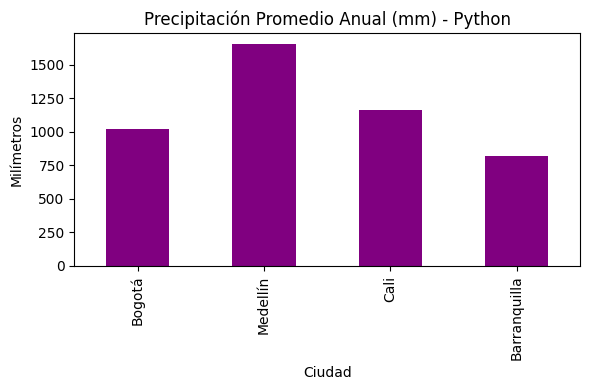

In [33]:
# 3. Visualización Básica de los datos limpios
fig, ax = plt.subplots(figsize=(6, 4))
df_limpio.plot.bar(x="Ciudad", y="Precipitacion_Anual", ax=ax, color="purple", legend=False)
ax.set_title("Precipitación Promedio Anual (mm) - Python")
ax.set_ylabel("Milímetros")
plt.tight_layout()
plt.show()